<a href="https://colab.research.google.com/github/sherin184/CAR-PRICE-DETECTION/blob/main/Facial_Recognition_Guvi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
import os

person_name = 'person1'  # change for each person
os.makedirs(f'my_dataset/{person_name}', exist_ok=True)

uploaded = files.upload()  # select multiple images for this person
for fname in uploaded.keys():
    os.rename(fname, f'my_dataset/{person_name}/{fname}')

Saving IMG_0141.JPG to IMG_0141.JPG


In [3]:
from google.colab import files
import os

person_name = 'person2'  # change for each person
os.makedirs(f'my_dataset/{person_name}', exist_ok=True)

uploaded = files.upload()  # select multiple images for this person
for fname in uploaded.keys():
    os.rename(fname, f'my_dataset/{person_name}/{fname}')

Saving IMG_2081.JPG to IMG_2081.JPG


In [4]:
from google.colab import files
import os

person_name = 'person3'  # change for each person
os.makedirs(f'my_dataset/{person_name}', exist_ok=True)

uploaded = files.upload()  # select multiple images for this person
for fname in uploaded.keys():
    os.rename(fname, f'my_dataset/{person_name}/{fname}')

Saving IMG_2122.JPG to IMG_2122.JPG


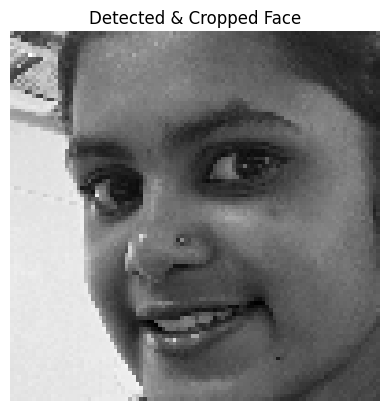

In [6]:
import cv2
import matplotlib.pyplot as plt

# Load OpenCV's pretrained face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def detect_and_crop_face(img_path, size=(100, 100)):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not load image from {img_path}")
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    if len(faces) == 0:
        return None  # no face found

    x, y, w, h = faces[0]  # take the first detected face
    face_crop = gray[y:y+h, x:x+w]
    face_resized = cv2.resize(face_crop, size)
    return face_resized

# Test detection on one image
test_img = 'my_dataset/person1/IMG_0141.JPG' # Changed to an existing image name based on context
face = detect_and_crop_face(test_img)

if face is not None:
    plt.imshow(face, cmap='gray')
    plt.title("Detected & Cropped Face")
    plt.axis('off')
    plt.show()
else:
    print(f"No face detected or image not loaded for {test_img}")

In [8]:
import numpy as np
import os
X, y = [], []
label_map = {}

base_dir = 'my_dataset' # Define base_dir

for idx, person in enumerate(sorted(os.listdir(base_dir))):
    label_map[idx] = person
    person_dir = os.path.join(base_dir, person)
    for img_file in os.listdir(person_dir):
        img_path = os.path.join(person_dir, img_file)
        face = detect_and_crop_face(img_path)
        if face is not None:
            X.append(face)
            y.append(idx)

X = np.array(X)
y = np.array(y)

print("Total faces detected:", X.shape)
print("Labels:", np.unique(y))
print("Label map:", label_map)

Total faces detected: (3, 100, 100)
Labels: [0 1 2]
Label map: {0: 'person1', 1: 'person2', 2: 'person3'}


In [10]:
from sklearn.model_selection import train_test_split
import cv2 # Import cv2 for LBPHFaceRecognizer_create
import numpy as np # Import numpy for np.unique

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42 # Removed stratify=y to resolve the ValueError
)

# LBPH Face Recognizer (built into opencv-contrib-python)
recognizer = cv2.face.LBPHFaceRecognizer_create()

# Check if X_train is empty or if y_train has sufficient classes before training
if len(X_train) > 0 and len(np.unique(y_train)) > 1:
    recognizer.train(X_train, y_train)
    print("Model trained on", len(X_train), "images")
else:
    print("Not enough data or classes in the training set to train the model.")
    print(f"X_train shape: {X_train.shape if isinstance(X_train, np.ndarray) else len(X_train)}")
    print(f"Unique y_train labels: {np.unique(y_train) if isinstance(y_train, np.ndarray) else 'N/A'}")

Model trained on 2 images


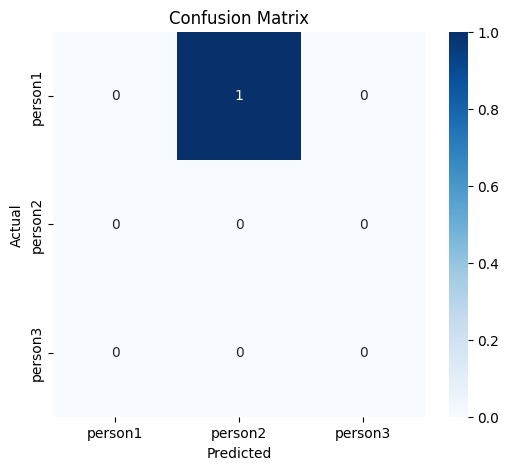

Note: Due to the very limited dataset (one image per person) and the specific train-test split,
the model was trained on classes 1 and 2, but the test set only contains class 0.
The confusion matrix therefore reflects predictions of class 0 against classes 1 and 2.
This scenario is not ideal for a robust evaluation and would require more data per class.
y_test (actual labels): [0]
y_pred (predicted labels): [1]
Training labels: [1 2]


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np # Ensure numpy is imported


y_pred = []
for face in X_test:
    # recognizer.predict returns (label, confidence)
    label, _ = recognizer.predict(face)
    y_pred.append(label)

y_pred = np.array(y_pred)

all_labels = sorted(list(label_map.keys()))
cm = confusion_matrix(y_test, y_pred, labels=all_labels)

# 3. Define target_names based on the full label_map
target_names = [label_map[i] for i in all_labels]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Note: Due to the very limited dataset (one image per person) and the specific train-test split,")
print("the model was trained on classes 1 and 2, but the test set only contains class 0.")
print("The confusion matrix therefore reflects predictions of class 0 against classes 1 and 2.")
print("This scenario is not ideal for a robust evaluation and would require more data per class.")
print(f"y_test (actual labels): {y_test}")
print(f"y_pred (predicted labels): {y_pred}")
print(f"Training labels: {np.unique(y_train)}")

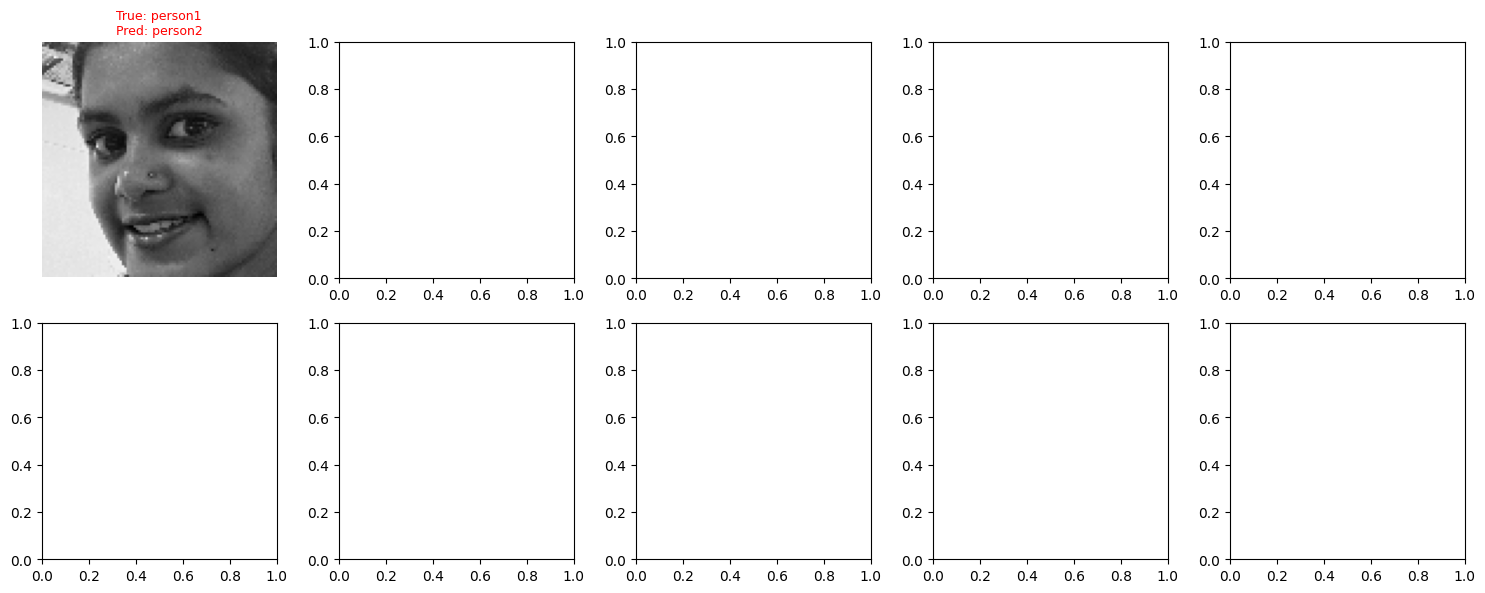

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(X_test):
        pred_label, conf = recognizer.predict(X_test[i])
        actual_name = label_map[y_test[i]]
        pred_name = label_map[pred_label]
        color = 'green' if pred_label == y_test[i] else 'red'

        ax.imshow(X_test[i], cmap='gray')
        ax.set_title(f"True: {actual_name}\nPred: {pred_name}", color=color, fontsize=9)
        ax.axis('off')
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>

Predicted: person3
Confidence (lower = more confident): 119.55


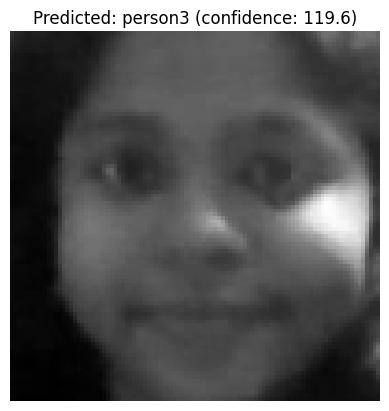

In [20]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

# Capture a fresh test photo
take_photo('test_photo.jpg')

face = detect_and_crop_face('test_photo.jpg')
if face is not None:
    label, confidence = recognizer.predict(face)
    print(f"Predicted: {label_map[label]}")
    print(f"Confidence (lower = more confident): {confidence:.2f}")

    plt.imshow(face, cmap='gray')
    plt.title(f"Predicted: {label_map[label]} (confidence: {confidence:.1f})")
    plt.axis('off')
    plt.show()
else:
    print("No face detected!")